# Балансировка классов и финальная очистка

Ноутбук выполняет балансировку классов в очищенном датасете через добавление спама из внешнего датасета HuggingFace (`ruSpamModels/russian-spam-detection`) с length-stratified sampling. При необходимости добавляется также ham для улучшения баланса по длинам сообщений.

Этапы:
1. Анализ текущего дисбаланса классов и распределения длин
2. Загрузка внешнего датасета с HuggingFace
3. Очистка внешних данных (фильтрация, дедупликация, удаление пересечений)
4. Length-stratified sampling спама для балансировки ratio = 1.0
5. Опциональное добавление ham при переполнении спама в отдельных бинах
6. Финальная очистка через MinHash LSH (near-дедупликация новых данных)
7. Анализ результата и сохранение

Загружается `data/interim/cleaned.csv` (результат 01b), сохраняется в `data/interim/balanced.csv`.

## Импорт необходимых библиотек

Используются `pandas`, `numpy`, `datasets` (HuggingFace), `datasketch` (MinHash LSH), `scipy` (KS-тест) и модули проекта.

In [1]:
import os
import re
import sys
import numpy as np
import pandas as pd

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.config import RAW_DIR, EXTERNAL_DIR, INTERIM_DIR
from src.data.loaders import load_txt_lines

from datasets import load_dataset
from datasketch import MinHash, MinHashLSH
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_STATE = 42

## Загрузка очищенного датасета

Загружается результат ноутбука `01b_data_cleaning.ipynb` — `data/interim/cleaned.csv`.

In [2]:
df = pd.read_csv(INTERIM_DIR / 'cleaned.csv')
print(f'Загружено: {len(df)} строк')

Загружено: 111803 строк


## Анализ текущего дисбаланса

Визуализация распределения классов и длин сообщений до балансировки.

### Распределение классов

Подсчёт количества ham и spam, вычисление соотношения и дефицита спама.

In [3]:
_ham_count = len(df[df['label'] == 0])
_spam_count = len(df[df['label'] == 1])
_ratio = _spam_count / _ham_count

print(f'Всего: {len(df)} строк')
print(f'  Ham (0): {_ham_count}')
print(f'  Spam (1): {_spam_count}')
print(f'  Соотношение spam/ham: {_ratio:.2f}')
print(f'  Дефицит спама: {_ham_count - _spam_count} строк')

Всего: 111803 строк
  Ham (0): 59190
  Spam (1): 52613
  Соотношение spam/ham: 0.89
  Дефицит спама: 6577 строк


### Распределение длин сообщений

Гистограмма распределения длин по классам (нормализованная плотность).

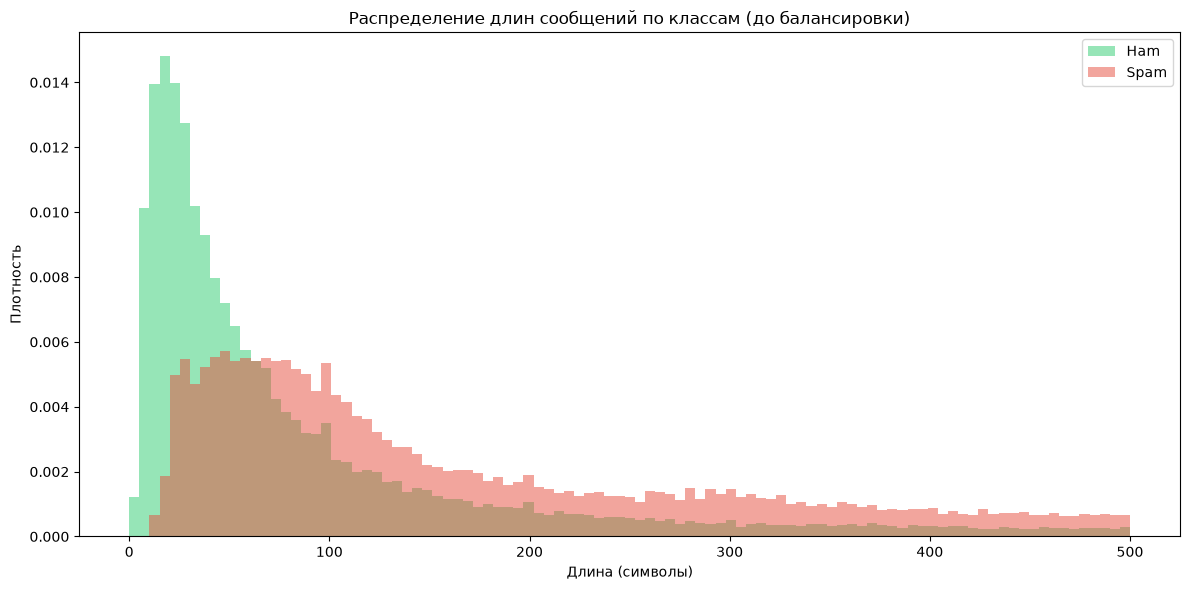

In [4]:
_fig, _ax = plt.subplots(figsize=(12, 6))

_ham_lens = df[df['label'] == 0]['text'].astype(str).str.len()
_spam_lens = df[df['label'] == 1]['text'].astype(str).str.len()

_bins = np.linspace(0, 500, 100)
_ax.hist(_ham_lens, bins=_bins, alpha=0.5, label='Ham', color='#2ecc71', density=True)
_ax.hist(_spam_lens, bins=_bins, alpha=0.5, label='Spam', color='#e74c3c', density=True)
_ax.set_title('Распределение длин сообщений по классам (до балансировки)')
_ax.set_xlabel('Длина (символы)')
_ax.set_ylabel('Плотность')
_ax.legend()
plt.tight_layout()
plt.show()

### Статистика длин по классам

Описательная статистика (mean, median, percentiles) для длин сообщений каждого класса.

In [5]:
_ham_stats = _ham_lens.describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])
_spam_stats = _spam_lens.describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])

_stats_df = pd.DataFrame({'Ham': _ham_stats, 'Spam': _spam_stats})
print(_stats_df)

                Ham          Spam
count  59190.000000  52613.000000
mean     162.550938    273.085416
std      282.061855    336.956045
min        5.000000      9.000000
10%       14.000000     41.000000
25%       26.000000     73.000000
50%       56.000000    148.000000
75%      149.000000    358.000000
90%      464.000000    657.000000
95%      744.550000    874.000000
99%     1404.220000   1466.000000
max     3983.000000   4293.000000


### Распределение по бинам длин

Таблица: количество ham и spam по бинам длин, дефицит спама в каждом бине.

In [6]:
BIN_EDGES = [0, 20, 50, 100, 200, 500, 1000, 2000, 5000, np.inf]
BIN_LABELS = ['0-20', '20-50', '50-100', '100-200', '200-500', '500-1000', '1000-2000', '2000-5000', '5000+']

df['length_bin'] = pd.cut(df['text'].astype(str).str.len(), bins=BIN_EDGES, labels=BIN_LABELS, right=False)

_bin_table = df.groupby(['length_bin', 'label'], observed=False).size().unstack(fill_value=0)
_bin_table.columns = ['Ham', 'Spam']
_bin_table['Дефицит'] = (_bin_table['Ham'] - _bin_table['Spam']).clip(lower=0)
_bin_table

,Ham,Spam,Дефицит
length_bin,,,
0-20,10103,401,9702
20-50,17057,7009,10048
50-100,12109,11615,494
100-200,8011,11635,0
200-500,6468,13557,0
500-1000,3959,6767,0
1000-2000,1331,1380,0
2000-5000,152,249,0
5000+,0,0,0


## Загрузка внешнего датасета с HuggingFace

Загружается датасет `ruSpamModels/russian-spam-detection` (4.5M строк, ~10% спама) через `datasets.load_dataset` с использованием `HF_TOKEN` из `.env`.

In [7]:
_hf_token = os.environ.get('HF_TOKEN', '')
if not _hf_token:
    raise ValueError('HF_TOKEN не найден в переменных окружения')

_hf_dataset = load_dataset(
    'ruSpamModels/russian-spam-detection',
    token=_hf_token,
)
print(f'Загружено: {len(_hf_dataset["train"])} строк')

README.md:   0%|          | 0.00/744 [00:00<?, ?B/s]

processed_combined.parquet:   0%|          | 0.00/480M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4511513 [00:00<?, ? examples/s]

Загружено: 4511513 строк


### Разделение на spam и ham

Колонка `message` переименовывается в `text`. Датасет разделяется на спам (label=1) и ham (label=0).

In [8]:
_hf_df = _hf_dataset['train'].to_pandas()
_hf_df = _hf_df.rename(columns={'message': 'text'})

_hf_spam = _hf_df[_hf_df['label'] == 1].copy()
_hf_ham = _hf_df[_hf_df['label'] == 0].copy()

print(f'Внешний датасет: {len(_hf_df)} строк')
print(f'  Spam: {len(_hf_spam)} ({len(_hf_spam) / len(_hf_df) * 100:.1f}%)')
print(f'  Ham: {len(_hf_ham)} ({len(_hf_ham) / len(_hf_df) * 100:.1f}%)')

Внешний датасет: 4511513 строк
  Spam: 347040 (7.7%)
  Ham: 4164473 (92.3%)


## Очистка внешних данных

Применяется к spam и ham из внешнего датасета:
1. Удаление пустых и коротких текстов (< 5 символов)
2. Фильтрация текстов без буквенно-цифровых слов (>= 2 символа)
3. Точная дедупликация
4. Near-дедупликация (нормализованная)
5. Удаление пересечений с существующим датасетом
6. Удаление пересечений с тестовой выборкой

### Функция нормализации для near-дедупликации

Нормализация: lowercase, удаление пунктуации, нормализация пробелов, удаление эмодзи.

In [9]:
def _normalize_for_dedup(text):
    """Нормализация текста для поиска near-дубликатов."""
    text = str(text).lower().strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    import emoji as _emoji
    import regex as _regex
    _graphemes = _regex.findall(r'\X', text)
    text = ''.join(g for g in _graphemes if not _emoji.is_emoji(g))
    return text.strip()

### Функция очистки внешних данных

Выполняет фильтрацию, точный и нормализованный дедуп внешнего датафрейма.

In [10]:
def _clean_external(df_external, label_value):
    """Очистка внешних данных: фильтрация и дедупликация."""
    _df = df_external.copy()
    _df = _df[_df['text'].notna()]
    _df = _df[_df['text'].astype(str).str.strip() != '']
    _df = _df[_df['text'].astype(str).str.len() >= 5]
    _has_word = _df['text'].str.contains(r'\b[a-zA-Zа-яА-ЯёЁ0-9]{2,}\b', regex=True, na=False)
    _df = _df[_has_word]
    _df = _df.drop_duplicates(subset='text', keep='first')
    _df['_norm'] = _df['text'].astype(str).apply(_normalize_for_dedup)
    _df = _df.drop_duplicates(subset='_norm', keep='first')
    _df = _df.drop(columns=['_norm'])
    _df['label'] = label_value
    return _df.reset_index(drop=True)

### Запуск очистки

Очистка спама и ham из внешнего датасета.

In [11]:
_hf_spam_clean = _clean_external(_hf_spam, 1)
_hf_ham_clean = _clean_external(_hf_ham, 0)

print(f'Очищенный внешний спам: {len(_hf_spam_clean)} строк')
print(f'Очищенный внешний ham: {len(_hf_ham_clean)} строк')

Очищенный внешний спам: 320112 строк
Очищенный внешний ham: 4151351 строк


### Удаление пересечений с существующим датасетом

Удаляются тексты из внешнего датасета, которые уже присутствуют в очищенном датасете (точное и нормализованное совпадение).

In [12]:
_existing_texts = set(df['text'].astype(str).tolist())
_existing_norms = set(df['text'].astype(str).apply(_normalize_for_dedup).tolist())

for _df_ext in [_hf_spam_clean, _hf_ham_clean]:
    _df_ext['_norm'] = _df_ext['text'].astype(str).apply(_normalize_for_dedup)

_hf_spam_clean = _hf_spam_clean[~_hf_spam_clean['text'].isin(_existing_texts)]
_hf_spam_clean = _hf_spam_clean[~_hf_spam_clean['_norm'].isin(_existing_norms)]

_hf_ham_clean = _hf_ham_clean[~_hf_ham_clean['text'].isin(_existing_texts)]
_hf_ham_clean = _hf_ham_clean[~_hf_ham_clean['_norm'].isin(_existing_norms)]

_hf_spam_clean = _hf_spam_clean.drop(columns=['_norm']).reset_index(drop=True)
_hf_ham_clean = _hf_ham_clean.drop(columns=['_norm']).reset_index(drop=True)

print(f'После удаления пересечений с существующим датасетом:')
print(f'  Спам: {len(_hf_spam_clean)} строк')
print(f'  Ham: {len(_hf_ham_clean)} строк')

После удаления пересечений с существующим датасетом:
  Спам: 319027 строк
  Ham: 4148243 строк


### Удаление пересечений с тестовой выборкой

Удаляются тексты, пересекающиеся с `test_clear.json` и `parsed_lols_2023.txt`, чтобы избежать data leakage.

In [13]:
_test_texts = set()
_test_norms = set()

if os.path.exists(RAW_DIR / 'test_clear.json'):
    _df_test = pd.read_json(RAW_DIR / 'test_clear.json')
    _test_texts.update(_df_test['text'].astype(str).tolist())
    _test_norms.update(_normalize_for_dedup(t) for t in _test_texts)

if os.path.exists(EXTERNAL_DIR / 'parsed_lols_2023.txt'):
    _lines_2023 = load_txt_lines(EXTERNAL_DIR / 'parsed_lols_2023.txt')
    _spam_2023 = set(
        l.replace('<br/>', '', 1).strip().replace('<br/>', '\n')
        for l in _lines_2023 if l.strip()
    )
    _test_texts.update(_spam_2023)
    _test_norms.update(_normalize_for_dedup(t) for t in _spam_2023)

for _df_ext in [_hf_spam_clean, _hf_ham_clean]:
    _df_ext['_norm'] = _df_ext['text'].astype(str).apply(_normalize_for_dedup)

_hf_spam_clean = _hf_spam_clean[~_hf_spam_clean['text'].isin(_test_texts)]
_hf_spam_clean = _hf_spam_clean[~_hf_spam_clean['_norm'].isin(_test_norms)]

_hf_ham_clean = _hf_ham_clean[~_hf_ham_clean['text'].isin(_test_texts)]
_hf_ham_clean = _hf_ham_clean[~_hf_ham_clean['_norm'].isin(_test_norms)]

_hf_spam_clean = _hf_spam_clean.drop(columns=['_norm']).reset_index(drop=True)
_hf_ham_clean = _hf_ham_clean.drop(columns=['_norm']).reset_index(drop=True)

print(f'После удаления пересечений с тестовой выборкой:')
print(f'  Спам: {len(_hf_spam_clean)} строк')
print(f'  Ham: {len(_hf_ham_clean)} строк')

После удаления пересечений с тестовой выборкой:
  Спам: 319013 строк
  Ham: 4147485 строк


## Length-stratified sampling спама

Сэмплинг спама из внешнего датасета по бинам длин. Количество спама в каждом бине определяется дефицитом: `max(0, ham_count - spam_count)`. Сумма дефицитов нормализуется к общему дефициту спама.

### Подсчёт дефицита спама по бинам

Для каждого бина длины вычисляется, сколько спама не хватает до количества ham.

In [14]:
_ham_bins = pd.cut(_ham_lens, bins=BIN_EDGES, labels=BIN_LABELS, right=False)
_spam_bins = pd.cut(_spam_lens, bins=BIN_EDGES, labels=BIN_LABELS, right=False)

_ham_counts = _ham_bins.value_counts().sort_index()
_spam_counts = _spam_bins.value_counts().sort_index()

_deficit = (_ham_counts - _spam_counts).clip(lower=0)
_total_deficit = int(_deficit.sum())

print(f'Дефицит спама по бинам:')
for _label, _val in _deficit.items():
    if _val > 0:
        print(f'  {_label}: {_val}')
print(f'\nОбщий дефицит: {_total_deficit} строк')

Дефицит спама по бинам:
  0-20: 9702
  20-50: 10048
  50-100: 494

Общий дефицит: 20244 строк


### Сэмплинг спама из внешнего датасета

Из очищенного внешнего спама выбирается нужное количество строк по каждому бину длины. Если в каком-то бине не хватает спама, остаток перераспределяется по другим бинам.

In [15]:
_hf_spam_clean['length_bin'] = pd.cut(
    _hf_spam_clean['text'].astype(str).str.len(),
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=False,
)

_sampled_parts = []
_remaining = _total_deficit

for _label in BIN_LABELS:
    _need = int(_deficit.get(_label, 0))
    if _need <= 0:
        continue
    _pool = _hf_spam_clean[_hf_spam_clean['length_bin'] == _label]
    _take = min(_need, len(_pool), _remaining)
    if _take <= 0:
        continue
    _sampled = _pool.sample(n=_take, random_state=RANDOM_STATE)
    _sampled_parts.append(_sampled)
    _remaining -= _take

if _remaining > 0:
    _used_texts = set()
    for _part in _sampled_parts:
        _used_texts.update(_part['text'].tolist())
    _leftover = _hf_spam_clean[~_hf_spam_clean['text'].isin(_used_texts)]
    _extra = _leftover.sample(n=min(_remaining, len(_leftover)), random_state=RANDOM_STATE + 1)
    _sampled_parts.append(_extra)
    _remaining -= len(_extra)

df_spam_new = pd.concat(_sampled_parts, ignore_index=True) if _sampled_parts else pd.DataFrame(columns=['text', 'label'])
df_spam_new = df_spam_new.drop(columns=['length_bin'], errors='ignore')
df_spam_new['_source'] = 'ruSpamModels/russian-spam-detection'

print(f'Добавлено спама: {len(df_spam_new)} строк')
if _remaining > 0:
    print(f'Не удалось добавить: {_remaining} строк (нехватка в внешнем датасете)')

Добавлено спама: 20244 строк


## Опциональное добавление ham

После добавления спама проверяется близость распределений длин. Если в каких-то бинах spam > ham, добавляется ham из внешнего датасета. Затем при необходимости доливается спам для сохранения ratio = 1.0.

### Проверка распределения после добавления спама

Объединение исходного датасета с новым спамом, проверка соотношения классов и распределения длин через KS-тест.

In [16]:
df_combined = pd.concat([df.drop(columns=['length_bin']), df_spam_new], ignore_index=True)

_ham_new = len(df_combined[df_combined['label'] == 0])
_spam_new = len(df_combined[df_combined['label'] == 1])

print(f'После добавления спама:')
print(f'  Ham: {_ham_new}')
print(f'  Spam: {_spam_new}')
print(f'  Ratio: {_spam_new / _ham_new:.2f}')

_ham_lens_new = df_combined[df_combined['label'] == 0]['text'].astype(str).str.len()
_spam_lens_new = df_combined[df_combined['label'] == 1]['text'].astype(str).str.len()

_ks_stat, _ks_p = stats.ks_2samp(_ham_lens_new, _spam_lens_new)
print(f'\nKS-тест: statistic={_ks_stat:.4f}, p-value={_ks_p:.4e}')

_ham_bins_new = pd.cut(_ham_lens_new, bins=BIN_EDGES, labels=BIN_LABELS, right=False).value_counts().sort_index()
_spam_bins_new = pd.cut(_spam_lens_new, bins=BIN_EDGES, labels=BIN_LABELS, right=False).value_counts().sort_index()

_imbalance = (_spam_bins_new - _ham_bins_new).clip(lower=0)
_total_ham_needed = int(_imbalance.sum())

if _total_ham_needed > 0:
    print(f'\nПереполнение спама по бинам (нужно добавить ham):')
    for _label, _val in _imbalance.items():
        if _val > 0:
            print(f'  {_label}: {_val}')
    print(f'Общий избыток: {_total_ham_needed} строк')
else:
    print(f'\nПереполнения спама нет — добавление ham не требуется')

После добавления спама:
  Ham: 59190
  Spam: 72857
  Ratio: 1.23

KS-тест: statistic=0.2451, p-value=0.0000e+00

Переполнение спама по бинам (нужно добавить ham):
  20-50: 594
  50-100: 3681
  100-200: 7441
  200-500: 8458
  500-1000: 2809
  1000-2000: 49
  2000-5000: 97
Общий избыток: 23129 строк


### Добавление ham при необходимости

Если в каких-то бинах spam > ham, добавляется ham из внешнего датасета по тем же бинам. После добавления ham пересчитывается дефицит спама и при необходимости доливается спам.

In [17]:
if _total_ham_needed > 0:
    _hf_ham_clean['length_bin'] = pd.cut(
        _hf_ham_clean['text'].astype(str).str.len(),
        bins=BIN_EDGES,
        labels=BIN_LABELS,
        right=False,
    )

    _ham_sampled_parts = []
    _ham_remaining = _total_ham_needed

    for _label in BIN_LABELS:
        _need = int(_imbalance.get(_label, 0))
        if _need <= 0:
            continue
        _pool = _hf_ham_clean[_hf_ham_clean['length_bin'] == _label]
        _take = min(_need, len(_pool), _ham_remaining)
        if _take <= 0:
            continue
        _sampled = _pool.sample(n=_take, random_state=RANDOM_STATE)
        _ham_sampled_parts.append(_sampled)
        _ham_remaining -= _take

    df_ham_new = pd.concat(_ham_sampled_parts, ignore_index=True) if _ham_sampled_parts else pd.DataFrame(columns=['text', 'label'])
    df_ham_new = df_ham_new.drop(columns=['length_bin'], errors='ignore')
    df_ham_new['_source'] = 'ruSpamModels/russian-spam-detection'

    df_combined = pd.concat([df_combined, df_ham_new], ignore_index=True)

    _ham_after = len(df_combined[df_combined['label'] == 0])
    _spam_after = len(df_combined[df_combined['label'] == 1])
    _deficit_after = _ham_after - _spam_after

    if _deficit_after > 0:
        _used = set(df_spam_new['text'].tolist())
        _leftover_spam = _hf_spam_clean[~_hf_spam_clean['text'].isin(_used)]
        _leftover_spam = _leftover_spam.drop(columns=['length_bin'], errors='ignore')
        _extra = _leftover_spam.sample(n=min(_deficit_after, len(_leftover_spam)), random_state=RANDOM_STATE + 2)
        _extra['_source'] = 'ruSpamModels/russian-spam-detection'
        df_combined = pd.concat([df_combined, _extra], ignore_index=True)

    print(f'Добавлено ham: {len(df_ham_new)} строк')
else:
    df_ham_new = pd.DataFrame(columns=['text', 'label'])
    print('Добавление ham не потребовалось')

_ham_final = len(df_combined[df_combined['label'] == 0])
_spam_final = len(df_combined[df_combined['label'] == 1])
print(f'\nТекущее соотношение: {_spam_final / _ham_final:.2f}')
print(f'  Ham: {_ham_final}, Spam: {_spam_final}')

Добавлено ham: 23129 строк

Текущее соотношение: 1.00
  Ham: 82319, Spam: 82319


## Финальная очистка через MinHash LSH

Проверка новых данных на near-дубликаты с существующим датасетом через MinHash LSH (Jaccard similarity >= 0.8). Найденные дубликаты удаляются, при необходимости производится доливка.

### Функции MinHash LSH

Шинглы — 3-граммы на нормализованном тексте. Порог Jaccard similarity — 0.8.

In [18]:
NUM_PERM = 128
JACCARD_THRESHOLD = 0.8
SHINGLE_SIZE = 3

In [19]:
def _shingles(text, k=SHINGLE_SIZE):
    """Разбивает текст на k-шинглы (символьные n-граммы)."""
    if len(text) < k:
        return {text}
    return {text[i:i + k] for i in range(len(text) - k + 1)}

In [20]:
def _make_minhash(text, num_perm=NUM_PERM):
    """Создаёт MinHash сигнатуру для текста."""
    mh = MinHash(num_perm=num_perm)
    for s in _shingles(text):
        mh.update(s.encode('utf-8'))
    return mh

### Поиск near-дубликатов среди новых данных

Строится LSH-индекс по существующим данным, затем новые данные запрашиваются против индекса. Найденные near-дубликаты удаляются.

In [21]:
_n_existing = len(df.drop(columns=['length_bin']))
_existing_df = df_combined.iloc[:_n_existing].copy()
_new_df = df_combined.iloc[_n_existing:].copy().reset_index(drop=True)

_existing_norms = _existing_df['text'].astype(str).apply(_normalize_for_dedup).tolist()

lsh = MinHashLSH(threshold=JACCARD_THRESHOLD, num_perm=NUM_PERM)
for _i, _text in enumerate(_existing_norms):
    _mh = _make_minhash(_text)
    lsh.insert(_i, _mh)

_new_norms = _new_df['text'].astype(str).apply(_normalize_for_dedup).tolist()
_to_remove = set()
for _j, _text in enumerate(_new_norms):
    _mh = _make_minhash(_text)
    _result = lsh.query(_mh)
    if len(_result) > 0:
        _to_remove.add(_j)

print(f'MinHash LSH: найдено {len(_to_remove)} near-дубликатов среди новых данных')

_new_cleaned = _new_df.drop(_new_df.index[list(_to_remove)]).reset_index(drop=True)
df_final = pd.concat([_existing_df, _new_cleaned], ignore_index=True)

MinHash LSH: найдено 638 near-дубликатов среди новых данных


### Доливка после MinHash-очистки

Если после удаления near-дубликатов баланс классов нарушился, производится доливка из остатка внешнего датасета.

In [22]:
_ham_f = len(df_final[df_final['label'] == 0])
_spam_f = len(df_final[df_final['label'] == 1])
_diff = _ham_f - _spam_f

if _diff > 0:
    _used_texts = set(df_spam_new['text'].tolist())
    _leftover = _hf_spam_clean[~_hf_spam_clean['text'].isin(_used_texts)]
    _leftover = _leftover.drop(columns=['length_bin'], errors='ignore')
    _leftover = _leftover[~_leftover['text'].isin(df_final['text'].astype(str).tolist())]
    if len(_leftover) >= _diff:
        _extra = _leftover.sample(n=_diff, random_state=RANDOM_STATE + 3)
        _extra['_source'] = 'ruSpamModels/russian-spam-detection'
        df_final = pd.concat([df_final, _extra], ignore_index=True)
        print(f'Долито спама после MinHash: {_diff} строк')
    else:
        print(f'Недостаточно внешнего спама для доливки: нужно {_diff}, доступно {len(_leftover)}')
elif _diff < 0:
    _surplus = -_diff
    _used_texts = set()
    if len(df_ham_new) > 0:
        _used_texts.update(df_ham_new['text'].tolist())
    _leftover = _hf_ham_clean[~_hf_ham_clean['text'].isin(_used_texts)]
    _leftover = _leftover.drop(columns=['length_bin'], errors='ignore')
    _leftover = _leftover[~_leftover['text'].isin(df_final['text'].astype(str).tolist())]
    if len(_leftover) >= _surplus:
        _extra = _leftover.sample(n=_surplus, random_state=RANDOM_STATE + 3)
        _extra['_source'] = 'ruSpamModels/russian-spam-detection'
        df_final = pd.concat([df_final, _extra], ignore_index=True)
        print(f'Долито ham после MinHash: {_surplus} строк')
    else:
        print(f'Недостаточно внешнего ham для доливки: нужно {_surplus}, доступно {len(_leftover)}')
else:
    print('Доливка не требуется — классы сбалансированы')

df_final = df_final.reset_index(drop=True)

_ham_f = len(df_final[df_final['label'] == 0])
_spam_f = len(df_final[df_final['label'] == 1])
print(f'\nФинальный датасет: {len(df_final)} строк')
print(f'  Ham: {_ham_f}')
print(f'  Spam: {_spam_f}')
print(f'  Ratio: {_spam_f / _ham_f:.2f}')

Долито спама после MinHash: 636 строк

Финальный датасет: 164636 строк
  Ham: 82318
  Spam: 82318
  Ratio: 1.00


## Анализ результата

Сравнение распределения классов и длин до и после балансировки.

### Сравнение распределения классов

Визуализация до и после балансировки.

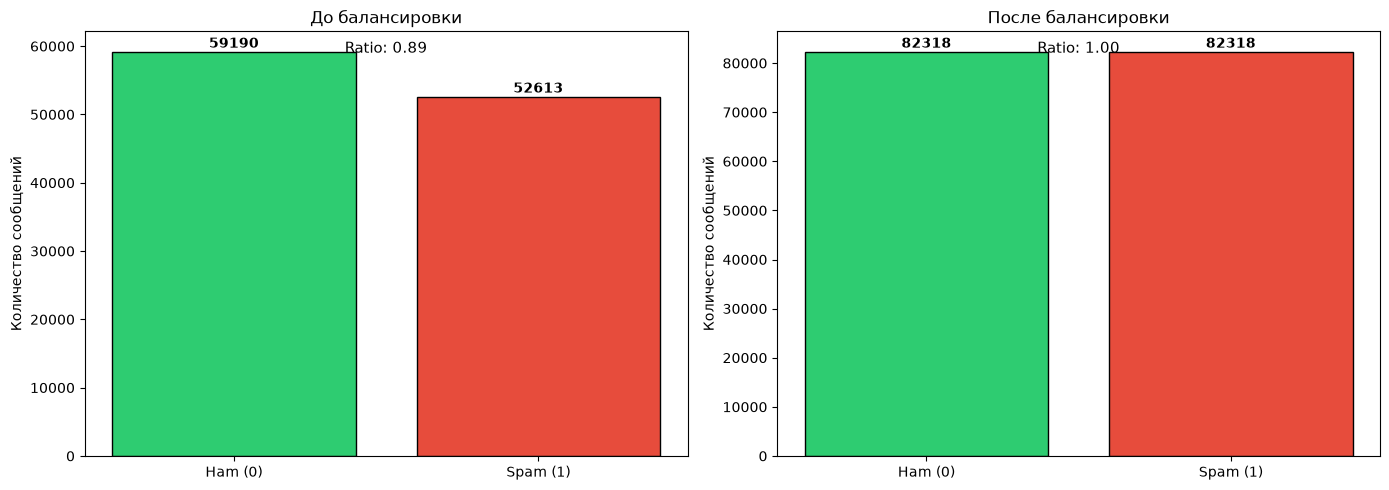

In [23]:
_fig, _axes = plt.subplots(1, 2, figsize=(14, 5))

for _ax, _df_plot, _title in [
    (_axes[0], df, 'До балансировки'),
    (_axes[1], df_final, 'После балансировки'),
]:
    _counts = _df_plot['label'].value_counts().sort_index()
    _ax.bar(['Ham (0)', 'Spam (1)'], _counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    for _i, _v in enumerate(_counts.values):
        _ax.text(_i, _v + max(_counts.values) * 0.01, str(_v), ha='center', fontweight='bold')
    _ax.set_title(_title)
    _ax.set_ylabel('Количество сообщений')
    _r = _counts.get(1, 0) / max(_counts.get(0, 1), 1)
    _ax.text(0.5, 0.95, f'Ratio: {_r:.2f}', transform=_ax.transAxes, ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### Сравнение распределения длин

Гистограмма распределения длин по классам до и после балансировки.

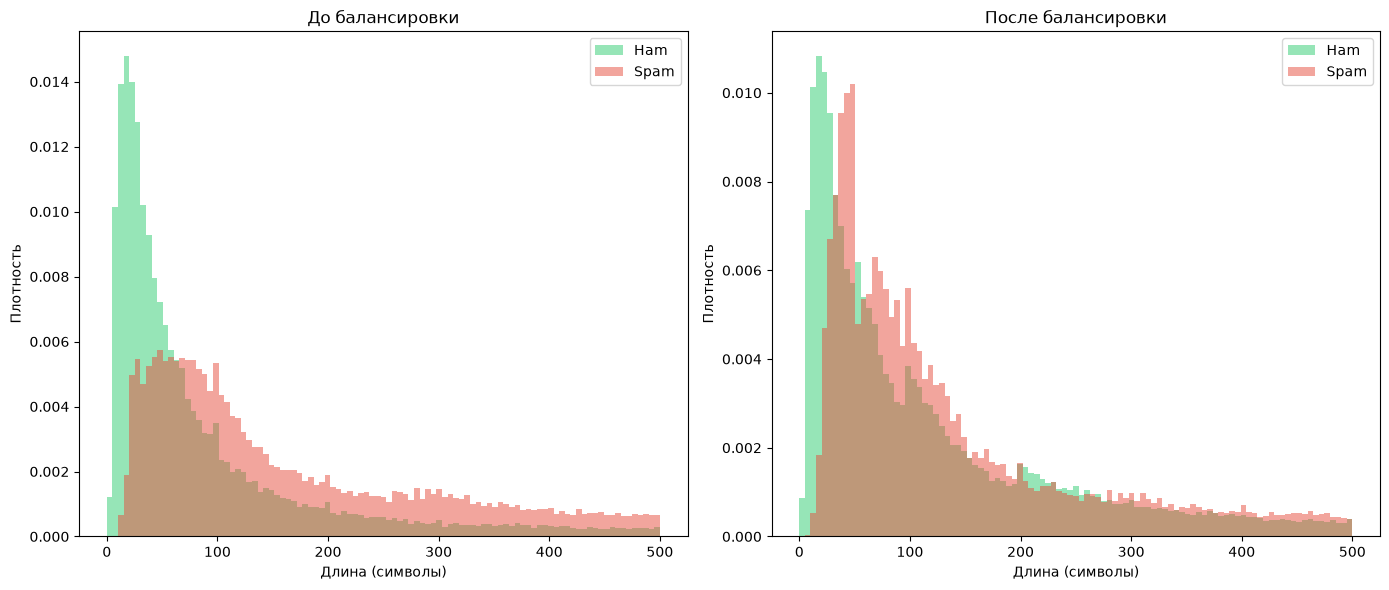

In [24]:
_fig, _axes = plt.subplots(1, 2, figsize=(14, 6))

for _ax, _df_plot, _title in [
    (_axes[0], df, 'До балансировки'),
    (_axes[1], df_final, 'После балансировки'),
]:
    _h = _df_plot[_df_plot['label'] == 0]['text'].astype(str).str.len()
    _s = _df_plot[_df_plot['label'] == 1]['text'].astype(str).str.len()
    _bins = np.linspace(0, 500, 100)
    _ax.hist(_h, bins=_bins, alpha=0.5, label='Ham', color='#2ecc71', density=True)
    _ax.hist(_s, bins=_bins, alpha=0.5, label='Spam', color='#e74c3c', density=True)
    _ax.set_title(_title)
    _ax.set_xlabel('Длина (символы)')
    _ax.set_ylabel('Плотность')
    _ax.legend()

plt.tight_layout()
plt.show()

### Таблица по бинам длин после балансировки

Сравнение количества ham и spam по бинам длин после балансировки.

In [25]:
_final_ham_lens = df_final[df_final['label'] == 0]['text'].astype(str).str.len()
_final_spam_lens = df_final[df_final['label'] == 1]['text'].astype(str).str.len()

_final_ham_bins = pd.cut(_final_ham_lens, bins=BIN_EDGES, labels=BIN_LABELS, right=False).value_counts().sort_index()
_final_spam_bins = pd.cut(_final_spam_lens, bins=BIN_EDGES, labels=BIN_LABELS, right=False).value_counts().sort_index()

_final_table = pd.DataFrame({'Ham': _final_ham_bins, 'Spam': _final_spam_bins})
_final_table['Разница'] = _final_table['Ham'] - _final_table['Spam']
_final_table

,Ham,Spam,Разница
text,,,
0-20,10103,639,9464
20-50,17651,18180,-529
50-100,15790,19597,-3807
100-200,15452,19236,-3784
200-500,14925,16269,-1344
500-1000,6768,6768,0
1000-2000,1380,1380,0
2000-5000,249,249,0
5000+,0,0,0


### KS-тест распределений длин

Количественная оценка близости распределений длин ham и spam после балансировки.

In [26]:
_ks_stat, _ks_p = stats.ks_2samp(_final_ham_lens, _final_spam_lens)
print(f'KS-тест после балансировки: statistic={_ks_stat:.4f}, p-value={_ks_p:.4e}')

_ks_before, _ = stats.ks_2samp(_ham_lens, _spam_lens)
print(f'KS-тест до балансировки:    statistic={_ks_before:.4f}')
print(f'Улучшение: {_ks_before - _ks_stat:.4f}')

KS-тест после балансировки: statistic=0.1624, p-value=0.0000e+00
KS-тест до балансировки:    statistic=0.3331
Улучшение: 0.1707


### Распределение по источникам

Статистика по источникам данных в финальном датасете.

In [27]:
if '_source' not in df_final.columns:
    df_final['_source'] = 'original'
    df_final.loc[df_final.index[:len(df)], '_source'] = df['_source'].values if '_source' in df.columns else 'original'

_source_table = df_final.groupby(['_source', 'label'], observed=False).size().unstack(fill_value=0)
if 0 in _source_table.columns and 1 in _source_table.columns:
    _source_table.columns = ['Ham', 'Spam']
_source_table

,Ham,Spam
_source,,
dataset.json,59190,52613
ruSpamModels/russian-spam-detection,23128,29705


## Сохранение сбалансированного датасета

Результат сохраняется в `data/interim/balanced.csv` для использования в следующем ноутбуке `01d_preprocessing.ipynb`.

In [28]:
df_final = df_final.drop(columns=['length_bin'], errors='ignore')
df_final.to_csv(INTERIM_DIR / 'balanced.csv', index=False)

_ham_s = len(df_final[df_final['label'] == 0])
_spam_s = len(df_final[df_final['label'] == 1])
print(f'Сохранено: {len(df_final)} строк в {INTERIM_DIR / "balanced.csv"}')
print(f'  Ham: {_ham_s}')
print(f'  Spam: {_spam_s}')
print(f'  Ratio: {_spam_s / _ham_s:.2f}')

Сохранено: 164636 строк в /home/sophrosyne/STANKIN_AntiSpam_Bot/data/interim/balanced.csv
  Ham: 82318
  Spam: 82318
  Ratio: 1.00
